In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
plt.style.use("ggplot")

In [3]:
df = pd.read_csv("fast_fashion_inventory.csv")
df.head()

,SKU_ID,Item_Description,Purchase_Cost_c,Retail_Price_r,Salvage_Value_v,Mean_Demand_mu,Std_Dev_sigma
0,TX-001,Heavy Winter Parka,45.0,130,15.0,850,120
1,TX-002,Limited Graphic Tee,8.5,28,2.0,2100,450
2,TX-003,Seasonal Denim Jacket,22.0,75,10.0,1100,200
3,TX-004,Cashmere Winter Scarf,14.0,55,5.0,600,95
4,TX-005,Summer Linen Shirt,12.5,45,4.0,1500,320


In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(20, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SKU_ID            20 non-null     object 
 1   Item_Description  20 non-null     object 
 2   Purchase_Cost_c   20 non-null     float64
 3   Retail_Price_r    20 non-null     int64  
 4   Salvage_Value_v   20 non-null     float64
 5   Mean_Demand_mu    20 non-null     int64  
 6   Std_Dev_sigma     20 non-null     int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.2+ KB
None
       Purchase_Cost_c  Retail_Price_r  Salvage_Value_v  Mean_Demand_mu  \
count        20.000000       20.000000        20.000000       20.000000   
mean         20.225000       65.700000         6.825000     1367.500000   
std          12.070489       34.404865         4.634751      679.449274   
min           8.500000       28.000000         1.500000      400.000000   
25%          12.875000   

In [5]:
print(df.isnull().sum())

SKU_ID              0
Item_Description    0
Purchase_Cost_c     0
Retail_Price_r      0
Salvage_Value_v     0
Mean_Demand_mu      0
Std_Dev_sigma       0
dtype: int64


In [6]:
## Overage cost
df["Overage_Cost"] = df["Purchase_Cost_c"] - df["Salvage_Value_v"]

In [7]:
## Underage Cost
df["Underage_Cost"] = df["Retail_Price_r"] - df["Purchase_Cost_c"]

In [8]:
## Critical Ratio
df["Critical_Ratio"] = (
    df["Underage_Cost"] /
    (df["Underage_Cost"] + df["Overage_Cost"])
)

In [9]:
## Z-Value
df["Z_Value"] = norm.ppf(df["Critical_Ratio"])

In [10]:
## Optimal Order Quantity
df["Optimal_Order_Qty"] = (
    df["Mean_Demand_mu"] +
    df["Z_Value"] * df["Std_Dev_sigma"]
)

df["Optimal_Order_Qty"] = (
    df["Optimal_Order_Qty"]
    .round()
    .astype(int)
)

In [11]:
## Expected Revenue
df["Expected_Revenue"] = (
    df["Mean_Demand_mu"] *
    df["Retail_Price_r"]
)

In [12]:
## Inventory Investment
df["Inventory_Investment"] = (
    df["Optimal_Order_Qty"] *
    df["Purchase_Cost_c"]
)

In [13]:
## Expected Gross Profit
df["Expected_Profit"] = (
    (df["Retail_Price_r"] - df["Purchase_Cost_c"])
    * df["Mean_Demand_mu"]
)

In [14]:
## Service Level
df["Service_Level"] = (
    df["Critical_Ratio"] * 100
).round(2)

In [15]:
## Final Result Table
result = df[
    [
        "SKU_ID",
        "Item_Description",
        "Purchase_Cost_c",
        "Retail_Price_r",
        "Salvage_Value_v",
        "Mean_Demand_mu",
        "Std_Dev_sigma",
        "Overage_Cost",
        "Underage_Cost",
        "Critical_Ratio",
        "Z_Value",
        "Optimal_Order_Qty",
        "Inventory_Investment",
        "Expected_Revenue",
        "Expected_Profit",
        "Service_Level"
    ]
]

result

,SKU_ID,Item_Description,Purchase_Cost_c,Retail_Price_r,Salvage_Value_v,Mean_Demand_mu,Std_Dev_sigma,Overage_Cost,Underage_Cost,Critical_Ratio,Z_Value,Optimal_Order_Qty,Inventory_Investment,Expected_Revenue,Expected_Profit,Service_Level
0,TX-001,Heavy Winter Parka,45.0,130,15.0,850,120,30.0,85.0,0.739130,0.640667,927,41715.0,110500,72250.0,73.91
1,TX-002,Limited Graphic Tee,8.5,28,2.0,2100,450,6.5,19.5,0.750000,0.674490,2404,20434.0,58800,40950.0,75.00
2,TX-003,Seasonal Denim Jacket,22.0,75,10.0,1100,200,12.0,53.0,0.815385,0.897915,1280,28160.0,82500,58300.0,81.54
3,TX-004,Cashmere Winter Scarf,14.0,55,5.0,600,95,9.0,41.0,0.820000,0.915365,687,9618.0,33000,24600.0,82.00
4,TX-005,Summer Linen Shirt,12.5,45,4.0,1500,320,8.5,32.5,0.792683,0.815766,1761,22012.5,67500,48750.0,79.27
5,TX-006,Floral Sundress,18.0,60,6.0,950,180,12.0,42.0,0.777778,0.764710,1088,19584.0,57000,39900.0,77.78
6,TX-007,Chunky Knit Sweater,25.0,85,8.0,1300,250,17.0,60.0,0.779221,0.769564,1492,37300.0,110500,78000.0,77.92
7,TX-008,Neon Swimwear Set,9.0,35,1.5,1800,50,7.5,26.0,0.776119,0.759153,1838,16542.0,63000,46800.0,77.61
8,TX-009,Faux Leather Leggings,11.5,40,3.0,2200,300,8.5,28.5,0.770270,0.739737,2422,27853.0,88000,62700.0,77.03
9,TX-010,Velvet Holiday Blazer,35.0,110,12.0,450,110,23.0,75.0,0.765306,0.723476,530,18550.0,49500,33750.0,76.53


In [16]:
## Highest Order Quantity
result.nlargest(
    5,
    "Optimal_Order_Qty"
)[
    ["SKU_ID",
     "Item_Description",
     "Optimal_Order_Qty"]
]

,SKU_ID,Item_Description,Optimal_Order_Qty
19,TX-020,Athleisure Zip-Up Hoodie,3127
12,TX-013,Organic Cotton Joggers,2814
8,TX-009,Faux Leather Leggings,2422
1,TX-002,Limited Graphic Tee,2404
13,TX-014,Thermal Baselayer Top,2072


In [17]:
## Lowest Order Quantity
result.nsmallest(
    5,
    "Optimal_Order_Qty"
)[
    ["SKU_ID",
     "Item_Description",
     "Optimal_Order_Qty"]
]

,SKU_ID,Item_Description,Optimal_Order_Qty
14,TX-015,Tweed Autumn Coat,457
9,TX-010,Velvet Holiday Blazer,530
3,TX-004,Cashmere Winter Scarf,687
11,TX-012,Festival Fringe Vest,876
18,TX-019,Embroidered Boho Tunic,894


In [18]:
## Highest Expected Profit
result.nlargest(
    5,
    "Expected_Profit"
)[
    ["SKU_ID",
     "Item_Description",
     "Expected_Profit"]
]

,SKU_ID,Item_Description,Expected_Profit
19,TX-020,Athleisure Zip-Up Hoodie,85400.0
16,TX-017,Retro Flared Jeans,78400.0
6,TX-007,Chunky Knit Sweater,78000.0
17,TX-018,Quilted Puffer Vest,73600.0
12,TX-013,Organic Cotton Joggers,72500.0


In [19]:
## Highest Inventory Investment
result.nlargest(
    5,
    "Inventory_Investment"
)[
    ["SKU_ID",
     "Item_Description",
     "Inventory_Investment"]
]

,SKU_ID,Item_Description,Inventory_Investment
19,TX-020,Athleisure Zip-Up Hoodie,45341.5
0,TX-001,Heavy Winter Parka,41715.0
6,TX-007,Chunky Knit Sweater,37300.0
12,TX-013,Organic Cotton Joggers,36582.0
16,TX-017,Retro Flared Jeans,36404.0


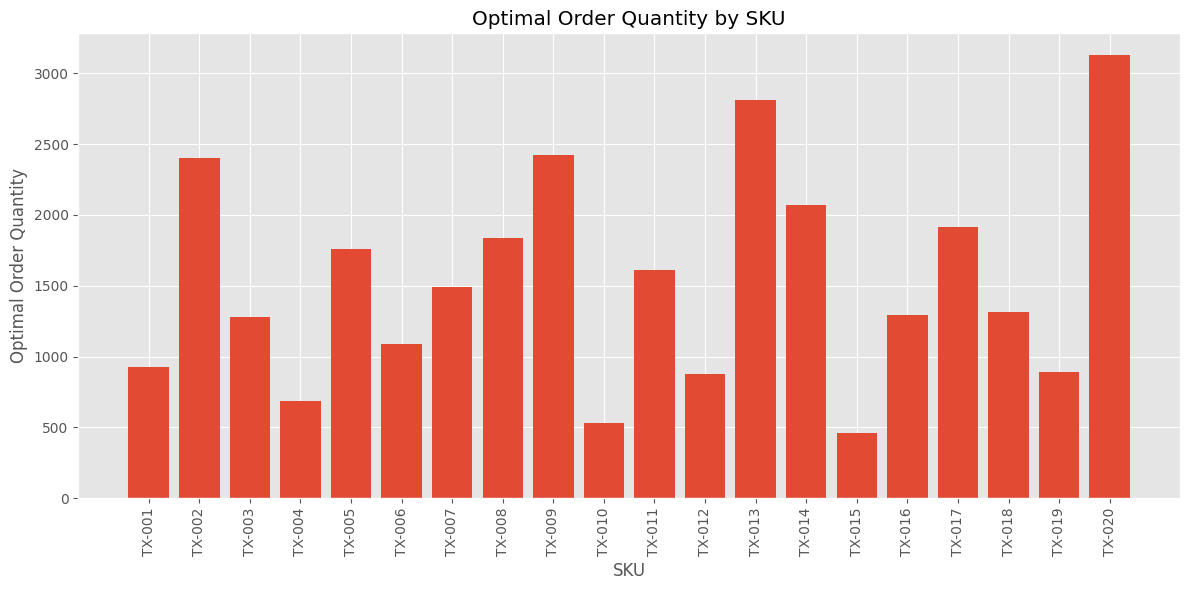

In [20]:
## Optimal Order Quantity
plt.figure(figsize=(12,6))

plt.bar(
    result["SKU_ID"],
    result["Optimal_Order_Qty"]
)

plt.xticks(rotation=90)

plt.title("Optimal Order Quantity by SKU")

plt.xlabel("SKU")

plt.ylabel("Optimal Order Quantity")

plt.tight_layout()

plt.show()

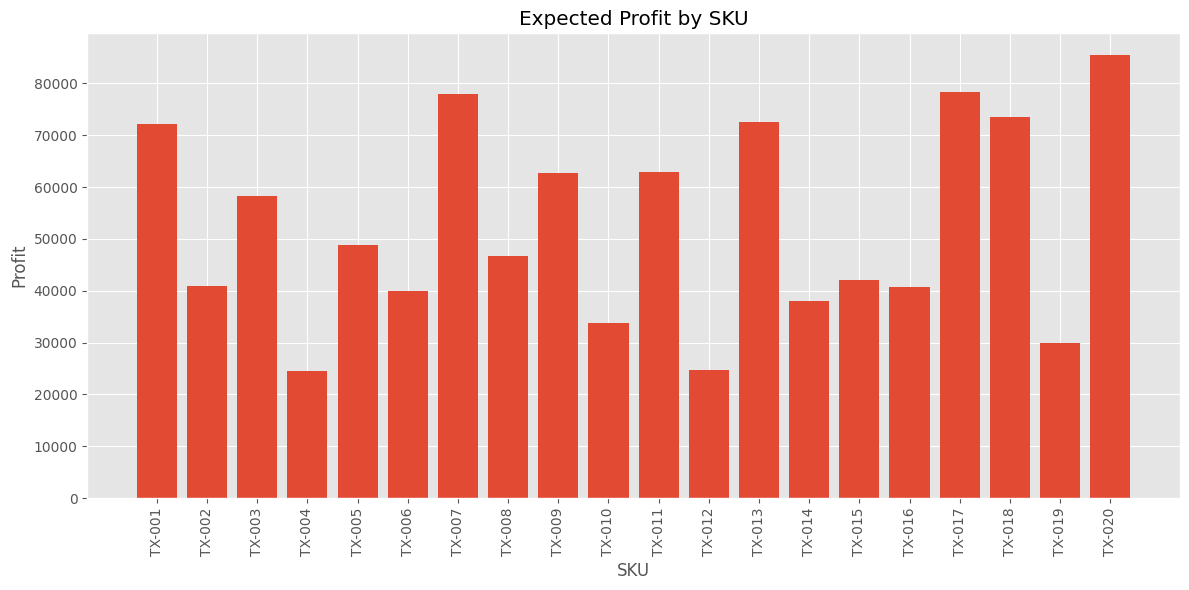

In [21]:
## Expected Profit
plt.figure(figsize=(12,6))

plt.bar(
    result["SKU_ID"],
    result["Expected_Profit"]
)

plt.xticks(rotation=90)

plt.title("Expected Profit by SKU")

plt.xlabel("SKU")

plt.ylabel("Profit")

plt.tight_layout()

plt.show()

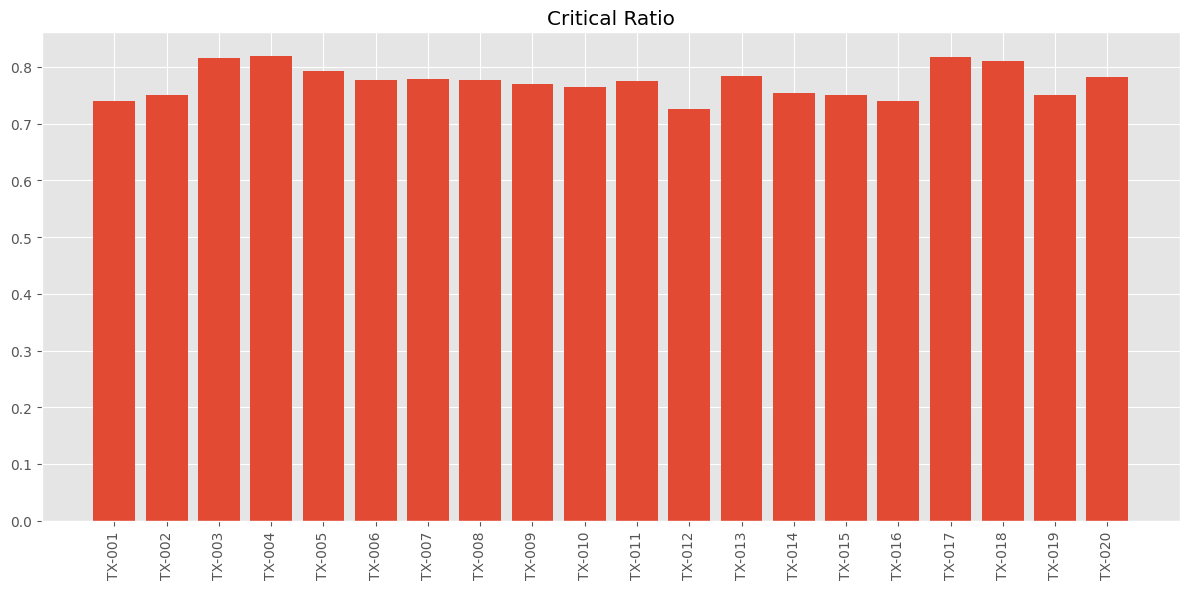

In [22]:
## Critical Ratio
plt.figure(figsize=(12,6))

plt.bar(
    result["SKU_ID"],
    result["Critical_Ratio"]
)

plt.xticks(rotation=90)

plt.title("Critical Ratio")

plt.tight_layout()

plt.show()

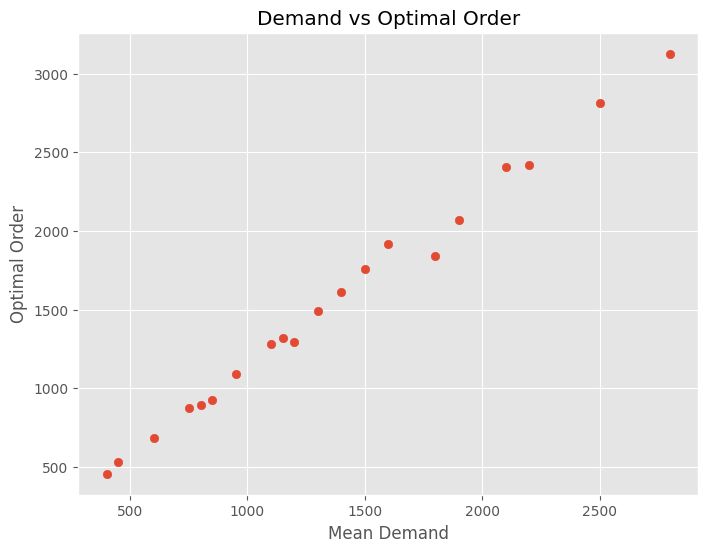

In [23]:
## Mean Demand vs Optimal Order Quantity
plt.figure(figsize=(8,6))

plt.scatter(
    result["Mean_Demand_mu"],
    result["Optimal_Order_Qty"]
)

plt.xlabel("Mean Demand")

plt.ylabel("Optimal Order")

plt.title("Demand vs Optimal Order")

plt.show()

In [29]:
## Scenario 1 (Demand +20%)
scenario1 = df.copy()

scenario1["Mean_Demand_mu"] *= 1.20

scenario1["Optimal_Order_Qty"] = (
    scenario1["Mean_Demand_mu"] +
    scenario1["Z_Value"] *
    scenario1["Std_Dev_sigma"]
).round()

In [30]:
## Scenario 2 (Demand -15%)
scenario2 = df.copy()

scenario2["Mean_Demand_mu"] *= 0.85

scenario2["Optimal_Order_Qty"] = (
    scenario2["Mean_Demand_mu"] +
    scenario2["Z_Value"] *
    scenario2["Std_Dev_sigma"]
).round()

In [31]:
## Scenario 3 (Salvage Value = 0)
scenario3 = df.copy()

scenario3["Salvage_Value_v"] = 0

scenario3["Overage_Cost"] = (
    scenario3["Purchase_Cost_c"] -
    scenario3["Salvage_Value_v"]
)

scenario3["Critical_Ratio"] = (
    scenario3["Underage_Cost"] /
    (
        scenario3["Underage_Cost"] +
        scenario3["Overage_Cost"]
    )
)

scenario3["Z_Value"] = norm.ppf(
    scenario3["Critical_Ratio"]
)

scenario3["Optimal_Order_Qty"] = (
    scenario3["Mean_Demand_mu"] +
    scenario3["Z_Value"] *
    scenario3["Std_Dev_sigma"]
).round()

In [32]:
result.to_csv(
    "fast_fashion_inventory.csv",
    index=False
)

In [33]:
print(result)

    SKU_ID          Item_Description  Purchase_Cost_c  Retail_Price_r  \
0   TX-001        Heavy Winter Parka             45.0             130   
1   TX-002       Limited Graphic Tee              8.5              28   
2   TX-003     Seasonal Denim Jacket             22.0              75   
3   TX-004     Cashmere Winter Scarf             14.0              55   
4   TX-005        Summer Linen Shirt             12.5              45   
5   TX-006           Floral Sundress             18.0              60   
6   TX-007       Chunky Knit Sweater             25.0              85   
7   TX-008         Neon Swimwear Set              9.0              35   
8   TX-009     Faux Leather Leggings             11.5              40   
9   TX-010     Velvet Holiday Blazer             35.0             110   
10  TX-011    Waterproof Windbreaker             20.0              65   
11  TX-012      Festival Fringe Vest             15.0              48   
12  TX-013    Organic Cotton Joggers             13